In [59]:
#Tarea 2:

In [60]:
#Let's first fix the path for the document to this: /Users/admin/Documents/ArquitecturaDeDatos

#1. Create a list with the names of the files in the directory
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import datetime
import time
from datetime import datetime
from datetime import date
from datetime import time

#path = "/Users/admin/Documents/ArquitecturaDeDatos/Tarea2"
#os.chdir(path)
#files = os.listdir(path)
#print(files)


In [61]:
#Now we define the files that are test and train  and we will read them
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
train.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


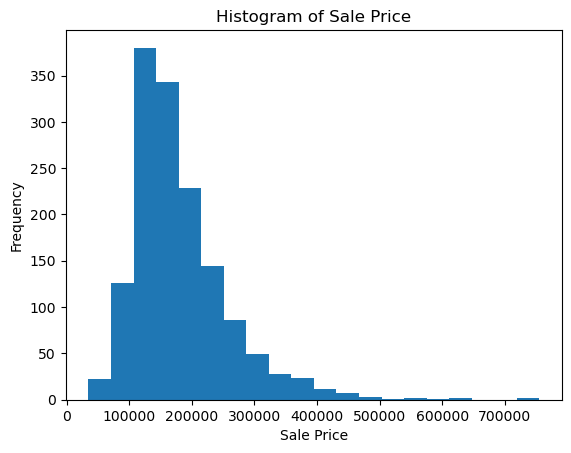

In [62]:
#Now we will run some EDA graphs to understand the data
#2. Create a histogram of the target variable, which is the variable SalePrice in the train dataset
plt.hist(train["SalePrice"], bins=20)
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.title("Histogram of Sale Price")
plt.show()


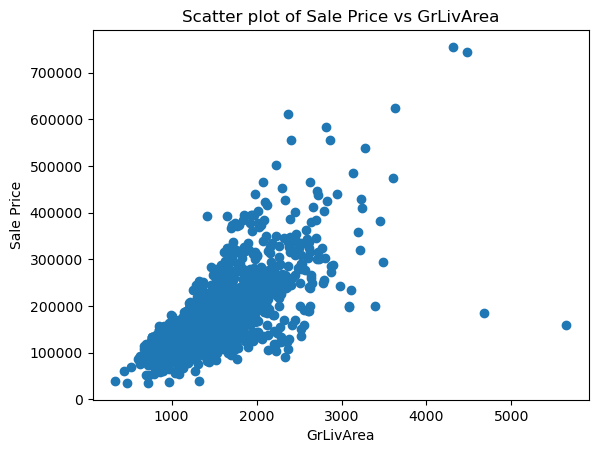

In [63]:
#Now some more EDA
#3. Create a scatter plot of the target variable versus the variable GrLivArea in the train dataset
plt.scatter(train["GrLivArea"], train["SalePrice"])
plt.xlabel("GrLivArea")
plt.ylabel("Sale Price")
plt.title("Scatter plot of Sale Price vs GrLivArea")
plt.show()

In [64]:
#Now we find the number of missing values in the train dataset for each variable
#4. Find the number of missing values in the train dataset for each variable, and display those that have at least one missing value
missing = train.isnull().sum()
missing = missing[missing > 0]
missing

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [65]:
#Now I also want to know the type of each variable
#5. Find the type of each variable in the train dataset
types = train.dtypes
types

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

In [66]:
#Are there variables that are text?
#6. Find the variables in the train dataset that are text
text = train.select_dtypes(include = "object")
text

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1,RL,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
3,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Detchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Abnorml
4,RL,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1456,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,...,Attchd,Unf,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal
1457,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,...,Attchd,RFn,TA,TA,Y,NaN,GdPrv,Shed,WD,Normal
1458,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Normal


In [67]:
#We remove the variables from each dataset that are text
train = train.select_dtypes(exclude = "object")
test = test.select_dtypes(exclude = "object")
#And display how many columns were eliminated from each dataset
print("Number of columns in train dataset: ", len(train.columns))
print("Number of columns in test dataset: ", len(test.columns))


Number of columns in train dataset:  38
Number of columns in test dataset:  37


In [68]:
#Now we do the same of finding missing values for the test dataset
#7. Find the number of missing values in the test dataset for each variable, and display those that have at least one missing value
missing = test.isnull().sum()
missing = missing[missing > 0]
missing

LotFrontage     227
MasVnrArea       15
BsmtFinSF1        1
BsmtFinSF2        1
BsmtUnfSF         1
TotalBsmtSF       1
BsmtFullBath      2
BsmtHalfBath      2
GarageYrBlt      78
GarageCars        1
GarageArea        1
dtype: int64

In [69]:
#Now we will fill the missing values in the train and test datasets with the mean of each variable
train = train.fillna(train.mean())
test = test.fillna(test.mean())


In [70]:
#Now we will do an xgboost model to predict the SalePrice in the test dataset, trained with the train dataset
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


In [71]:
#We need to do all the transformations we did above with the test dataset
#We remove the variables from each dataset that are text
train = train.select_dtypes(exclude = "object")
test = test.select_dtypes(exclude = "object")
#And display how many columns were eliminated from each dataset
print("Number of columns in train dataset: ", len(train.columns))
print("Number of columns in test dataset: ", len(test.columns))
#And fill the missing values in the test dataset with the mean of each variable
test = test.fillna(test.mean())

Number of columns in train dataset:  38
Number of columns in test dataset:  37


In [72]:
#I want to see a list of the columns in the train dataset
columns = train.columns
columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [73]:
#The train dataset is the train, the test is the validation
Xtrain = train.drop("SalePrice", axis = 1)
ytrain = train["SalePrice"]
Xtest = test
#ytest = test["SalePrice"]

In [74]:
#Now we will train the model
model = xgb.XGBRegressor()
model.fit(Xtrain, ytrain)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [75]:
#Now we will predict the SalePrice in the test dataset
predictions = model.predict(Xtest)
#And we will calculate the mean squared error
#mse = mean_squared_error(ytest, predictions)
#print("Mean Squared Error: ", mse)


In [76]:
import math

result = math.sqrt(869328192)
print(result)

29484.371996025286


In [77]:
#Now I want to create an interactive way that the user can input the values of the variables and the model will predict the SalePrice
#I will use the tkinter library
import tkinter as tk
from tkinter import simpledialog


In [82]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
import tkinter as tk
from tkinter import simpledialog

# Initialize tkinter
root = tk.Tk()
root.withdraw()

# Collect user input
GrLivArea = simpledialog.askfloat("GrLivArea", "Enter the GrLivArea: ")
GarageArea = simpledialog.askfloat("GarageArea", "Enter the GarageArea: ")
TotalBsmtSF = simpledialog.askfloat("TotalBsmtSF", "Enter the TotalBsmtSF: ")
FirstFlrSF = simpledialog.askfloat("FirstFlrSF", "Enter the FirstFlrSF: ")
FullBath = simpledialog.askfloat("FullBath", "Enter the FullBath: ")
TotRmsAbvGrd = simpledialog.askfloat("TotRmsAbvGrd", "Enter the TotRmsAbvGrd: ")
YearBuilt = simpledialog.askfloat("YearBuilt", "Enter the YearBuilt: ")
YearRemodAdd = simpledialog.askfloat("YearRemodAdd", "Enter the YearRemodAdd: ")
GarageYrBlt = simpledialog.askfloat("GarageYrBlt", "Enter the GarageYrBlt: ")
MasVnrArea = simpledialog.askfloat("MasVnrArea", "Enter the MasVnrArea: ")
Fireplaces = simpledialog.askfloat("Fireplaces", "Enter the Fireplaces: ")
BsmtFinSF1 = simpledialog.askfloat("BsmtFinSF1", "Enter the BsmtFinSF1: ")
LotFrontage = simpledialog.askfloat("LotFrontage", "Enter the LotFrontage: ")
LotArea = simpledialog.askfloat("LotArea", "Enter the LotArea: ")
WoodDeckSF = simpledialog.askfloat("WoodDeckSF", "Enter the WoodDeckSF: ")
OpenPorchSF = simpledialog.askfloat("OpenPorchSF", "Enter the OpenPorchSF: ")
HalfBath = simpledialog.askfloat("HalfBath", "Enter the HalfBath: ")
BsmtFullBath = simpledialog.askfloat("BsmtFullBath", "Enter the BsmtFullBath: ")
BsmtHalfBath = simpledialog.askfloat("BsmtHalfBath", "Enter the BsmtHalfBath: ")
BedroomAbvGr = simpledialog.askfloat("BedroomAbvGr", "Enter the BedroomAbvGr: ")
KitchenAbvGr = simpledialog.askfloat("KitchenAbvGr", "Enter the KitchenAbvGr: ")
EnclosedPorch = simpledialog.askfloat("EnclosedPorch", "Enter the EnclosedPorch: ")
ScreenPorch = simpledialog.askfloat("ScreenPorch", "Enter the ScreenPorch: ")
PoolArea = simpledialog.askfloat("PoolArea", "Enter the PoolArea: ")
MiscVal = simpledialog.askfloat("MiscVal", "Enter the MiscVal: ")
MoSold = simpledialog.askfloat("MoSold", "Enter the MoSold: ")
YrSold = simpledialog.askfloat("YrSold", "Enter the YrSold: ")

# Create a dictionary with the values
values = {
    "GrLivArea": GrLivArea, "GarageArea": GarageArea, "TotalBsmtSF": TotalBsmtSF, "1stFlrSF": FirstFlrSF, 
    "FullBath": FullBath, "TotRmsAbvGrd": TotRmsAbvGrd, "YearBuilt": YearBuilt, "YearRemodAdd": YearRemodAdd, 
    "GarageYrBlt": GarageYrBlt, "MasVnrArea": MasVnrArea, "Fireplaces": Fireplaces, "BsmtFinSF1": BsmtFinSF1, 
    "LotFrontage": LotFrontage, "LotArea": LotArea, "WoodDeckSF": WoodDeckSF, "OpenPorchSF": OpenPorchSF, 
    "HalfBath": HalfBath, "BsmtFullBath": BsmtFullBath, "BsmtHalfBath": BsmtHalfBath, "BedroomAbvGr": BedroomAbvGr, 
    "KitchenAbvGr": KitchenAbvGr, "EnclosedPorch": EnclosedPorch, "ScreenPorch": ScreenPorch, "PoolArea": PoolArea, 
    "MiscVal": MiscVal, "MoSold": MoSold, "YrSold": YrSold, "Id": 0, "MSSubClass": 0, "OverallQual": 0, 
    "OverallCond": 0, "BsmtFinSF2": 0, "BsmtUnfSF": 0, "2ndFlrSF": 0, "LowQualFinSF": 0, "GarageCars": 0, "3SsnPorch": 0
}

# Create a dataframe with the values
values_df = pd.DataFrame(values, index=[0])

# Ensure the columns are in the same order as the training data
values_df = values_df[['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']]

# Convert the dataframe to DMatrix
dmatrix = xgb.DMatrix(values_df)

# Load your trained model (assuming it's already loaded as 'model')
# model = xgb.Booster()  # Example: load your model here

# Predict the SalePrice
prediction = model.predict(dmatrix)
print("The predicted SalePrice is: ", prediction)

# Close the tkinter window
root.destroy()

/usr/local/Caskroom/miniconda/base/envs/arquitectura/lib/python3.11/site-packages/xgboost/data.py:1138: UserWarning: Unknown data type: <class 'xgboost.core.DMatrix'>, trying to convert it to csr_matrix
  warnings.warn(


TypeError: Not supported type for data.<class 'xgboost.core.DMatrix'>